# RNN, LSTM, and GRU for Sequential Data

**Unit:** Unit 4: Neural Networks Fundamentals

Every network we have trained so far looks at one *snapshot* — an image, a row of features — and forgets it immediately. But many real signals are *sequences* where order carries the meaning: sensor readings, stock prices, words in a sentence. To predict what comes next, a network needs **memory** of what came before. Recurrent networks add exactly that: a hidden state passed from one time step to the next. In `02_cnn_rnn_architectures.ipynb` we only printed these architectures' summaries; here we actually train the three classic recurrent cells — SimpleRNN, LSTM, and GRU — on the *same* forecasting task with the *same* hidden size and training budget, and let the measured validation error tell us which memory design works best on this task. The task uses a **real** signal: the number of 911 emergency calls logged in Montgomery County, Pennsylvania, in each six-hour block of the day.

## 📚 Learning Objectives

By completing this notebook, you will:
- Turn a continuous signal into (window -> next value) training sequences
- Explain intuitively what gates add: SimpleRNN vs. LSTM vs. GRU
- Train all three cells under an identical budget and compare validation MSE from actual results
- Read a predictions-vs-truth plot to judge forecast quality beyond a single number

## 🔗 Where this fits

**Builds on:** Unit 4, lesson 02 "Deep Learning Architectures: CNNs and RNNs" — the RNN described there is trained here against LSTM and GRU; all three learn by the Unit 3, lesson 04 recipe: define a loss, then use gradient descent to nudge the parameters.

**Used later in:** Course 08 (AIAT 122) — Unit 3 and Course 07 (AIAT 121) — Unit 4, where the same cells are used for language.

---


## 🎯 The day Google Translate changed engines

In **September 2016** Google replaced the statistical phrase-based system behind
Google Translate with **GNMT**: eight LSTM encoder layers and eight LSTM decoder
layers with attention. Google reported the new system reduced translation errors
by **55-85%** on several major language pairs, judged by bilingual human raters,
and it went to production first on Chinese→English. The recurrent cell in that
stack is the same `LSTM` you are about to train below — with more layers, far more
data, and a great deal more compute.

The sequel is just as instructive. A year later the transformer arrived, and
within a few years it had displaced recurrent stacks for most language work
because it can process a whole sequence in parallel instead of one timestep at a
time. **Gates were the answer to "how does memory survive many steps"; parallelism
was the answer to "how do we train on enough data".** Both answers are still
correct about the problem each solved.

### What goes wrong without memory

Every model so far in this course sees one snapshot and forgets it. Ask such a
model how many 911 calls to expect this evening and the best it can do is the
average evening — it cannot know that the last two days were unusually busy, that
yesterday was a public holiday, or that a storm started this afternoon. The forecast in
this notebook needs the *shape of the recent past*, and a hidden state carried
from one timestep to the next is the cheapest way to have it.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- A real time series built with `load("montgomery_911_calls", prefer="sample")` — the 25,000-row
  sample that ships inside this repository, so there is nothing to download and every machine
  (yours, the instructor's, Google Colab) reads exactly the same rows
- Calls counted per **6-hour block** rather than per clock hour: the sample keeps 1 call in 27, and
  a 0.6-calls-per-hour series is rounding noise where a 3.6-calls-per-block series is a signal
- Sliding windows of **40 past blocks** (10 days) used to predict the **call volume in the next block**

**Outputs:** What you'll see when you run the cells

- Printed dataset sizes and per-model parameter counts
- A table of final validation MSE for SimpleRNN, LSTM, and GRU
- One plot overlaying the three models' predictions against the true signal

---

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("montgomery_911_calls"), ...
# -------------------------------------------------------------------------------------

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
Real series: 2000 consecutive 6-hour blocks, 2015-12-10 18:00 -> 2017-04-23 12:00
Calls per block: min 0, mean 3.6, max 14
Correlation with the same block yesterday (lag 4): 0.733  <- a real daily rhythm

Training windows:  1568  (each is 40 blocks -> predict block 41)
Validation windows:  392  (the held-out later months)


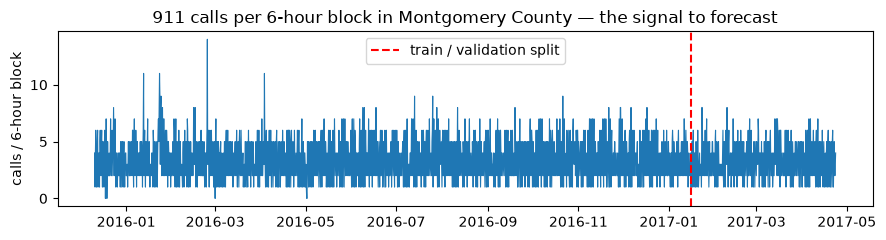

In [2]:
# Setup a forecasting task on a REAL signal: how many 911 emergency calls arrive in
# Montgomery County in each 6-hour block. We cut it into sliding windows of 40 past blocks
# -> predict block 41. Note the TIME-ORDERED split: validate on the future, never on
# shuffled rows.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

tf.get_logger().setLevel("ERROR")  # hide harmless tf.function retracing notices
keras.utils.set_random_seed(42)  # reproducible runs

# WHAT: read ONE column of the call log through the shared loader - that is all a volume
#       forecast needs. No path, so it works from any folder and on Google Colab.
# WHY prefer="sample": the full 123 MB log is a Kaggle download almost nobody in the class
#       will have. Pinning the bundled 25,000-row sample means your machine, the
#       instructor's machine and Colab all read the same rows and print the same numbers.
calls = load("montgomery_911_calls", prefer="sample", usecols=["timeStamp"])
stamps = pd.to_datetime(calls["timeStamp"], errors="coerce").dropna().sort_values()

# Count the calls that arrived in each 6-hour block (00-06, 06-12, 12-18, 18-24), then fill
# any empty block with 0 so the series sits on a complete, evenly spaced grid (recurrent
# nets assume that).
# WHY 6-hour blocks rather than clock hours: the bundled sample keeps 1 call in every 27,
# so an hourly count would average 0.6 calls and the day/night rhythm would drown in
# rounding noise. Six-hour blocks average about 3.6 calls and keep that rhythm intact.
BLOCK = "6h"
blocks = stamps.dt.floor(BLOCK).value_counts().sort_index().asfreq(BLOCK, fill_value=0)

N_BLOCKS = 2000                   # 2,000 x 6h = about 500 consecutive days
blocks = blocks.iloc[:N_BLOCKS]
raw_series = blocks.to_numpy(dtype="float64")
timeline = blocks.index

print(f"Real series: {len(raw_series)} consecutive 6-hour blocks, "
      f"{timeline[0]:%Y-%m-%d %H:%M} -> {timeline[-1]:%Y-%m-%d %H:%M}")
print(f"Calls per block: min {raw_series.min():.0f}, mean {raw_series.mean():.1f}, "
      f"max {raw_series.max():.0f}")
print(f"Correlation with the same block yesterday (lag 4): "
      f"{np.corrcoef(raw_series[:-4], raw_series[4:])[0, 1]:.3f}  <- a real daily rhythm")

# Sliding windows: 40 past blocks (10 days) -> predict the next block
WINDOW = 40

# Time-ordered split: train on the first 80% of windows, validate on the last 20%.
n_windows = len(raw_series) - WINDOW
n_train = int(0.8 * n_windows)

# Standardize using ONLY the training portion. WHY: the validation hours are the
# "future" — using their mean/std would leak information we would not have in production.
split_point = n_train + WINDOW
mu, sigma = raw_series[:split_point].mean(), raw_series[:split_point].std()
series = (raw_series - mu) / sigma

X = np.array([series[i : i + WINDOW] for i in range(n_windows)])[..., None].astype("float32")
y = np.array([series[i + WINDOW] for i in range(n_windows)]).astype("float32")

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:], y[n_train:]

print(f"\nTraining windows:  {len(X_train)}  (each is {WINDOW} blocks -> predict block {WINDOW + 1})")
print(f"Validation windows:{len(X_val):5d}  (the held-out later months)")

plt.figure(figsize=(9, 2.5))
plt.plot(timeline, raw_series, lw=0.8)
plt.axvline(timeline[split_point], color="red", ls="--", label="train / validation split")
plt.title("911 calls per 6-hour block in Montgomery County — the signal to forecast")
plt.ylabel("calls / 6-hour block")
plt.legend()
plt.tight_layout()
plt.show()

## Three ways to remember: SimpleRNN, LSTM, GRU

All three cells read the window one step at a time, carrying a hidden state forward. They differ in *how* that memory is managed:

- **SimpleRNN** — one memory vector, **overwritten at every step** (`new state = f(input, old
  state)`). There is no mechanism to protect old information, so what happened 40 steps ago has
  been rewritten 40 times and mostly fades away (the *vanishing gradient* problem from the
  lectures).
- **LSTM** — adds a separate *cell state* that flows through time like a conveyor belt, plus
  three **gates** (small learned valves outputting 0-1): the **forget gate** decides what to
  erase from the belt, the **input gate** decides what new information to write onto it, and the
  **output gate** decides how much of the belt to reveal at this step. Because information can
  ride the belt untouched, long-range patterns survive.
- **GRU** — the economy version of the LSTM: two gates instead of three (an **update gate**
  merging forget+input into one "keep old vs. take new" dial, and a **reset gate** controlling
  how much history feeds the new candidate). Fewer parameters, often similar quality.

**The experiment:** identical data, identical hidden size (32 units), identical epochs, optimizer, and batch size — the *only* change is the recurrent cell. Note honestly: same hidden width does **not** mean same parameter count, because the gates are extra weights; the printed counts below show it.

One thing real data adds: the series is **standardized using the training portion only**, so an MSE
near 1 means roughly "no better than always predicting the training average". The cell after next
prints the two baselines exactly; beating them is what makes the skill real, and one of them turns
out to be much harder to beat than the other.

In [3]:
# The fair comparison: SimpleRNN vs LSTM vs GRU in the SAME architecture, same data,
# same epochs — so the recurrent cell type is the only variable.
def build_model(cell_class):
    """Same architecture for all three: one recurrent layer (32 units) + linear output."""
    model = keras.Sequential(
        [keras.Input(shape=(WINDOW, 1)), cell_class(32), keras.layers.Dense(1)]
    )
    model.compile(optimizer="adam", loss="mse")
    return model

cells_to_test = [
    ("SimpleRNN", keras.layers.SimpleRNN),
    ("LSTM", keras.layers.LSTM),
    ("GRU", keras.layers.GRU),
]

EPOCHS = 15
results = {}
for name, cell_class in cells_to_test:
    keras.utils.set_random_seed(42)  # identical init/shuffling conditions for each model
    model = build_model(cell_class)
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=32, verbose=0)
    val_mse = model.evaluate(X_val, y_val, verbose=0)
    # keep the per-epoch history too: the learning curves are plotted further down
    results[name] = {"model": model, "params": model.count_params(),
                     "val_mse": val_mse, "history": hist.history}
    print(f"{name:9s} trained: {model.count_params():5,} parameters, "
          f"final val MSE = {val_mse:.4f}  ({EPOCHS} epochs)")

SimpleRNN trained: 1,121 parameters, final val MSE = 0.2389  (15 epochs)


LSTM      trained: 4,385 parameters, final val MSE = 0.2564  (15 epochs)


GRU       trained: 3,393 parameters, final val MSE = 0.2510  (15 epochs)


=== Final validation MSE, standardized units (same data, 32 units, 15 epochs each) ===
model        params   val MSE
SimpleRNN     1,121    0.2389
GRU           3,393    0.2510
LSTM          4,385    0.2564

Best on this run: SimpleRNN (val MSE 0.2389)

Baseline 'always predict the training average': val MSE 0.8560
Baseline 'repeat the previous block'           : val MSE 1.5842
All three recurrent cells beat both baselines — the daily rhythm really is learnable.


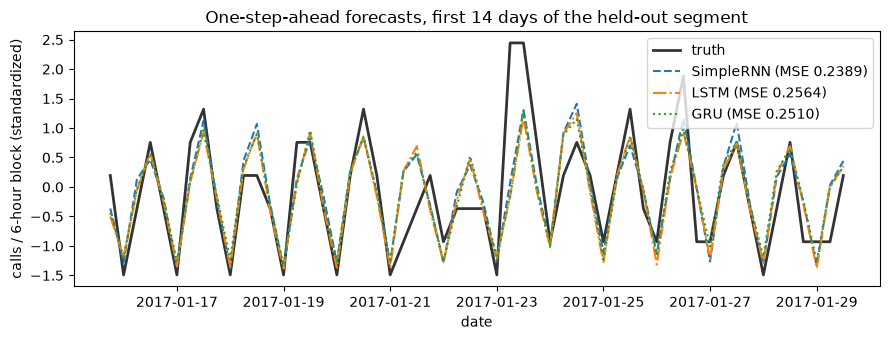

In [4]:
# Results: rank the three cells by validation MSE, then overlay their forecasts on
# the true held-out signal to see the errors, not just read them.
# One table of final validation MSE, ranked best (lowest) first
print("=== Final validation MSE, standardized units (same data, 32 units, 15 epochs each) ===")
print(f"{'model':<10} {'params':>8} {'val MSE':>9}")
ranked = sorted(results.items(), key=lambda kv: kv[1]["val_mse"])
for name, r in ranked:
    print(f"{name:<10} {r['params']:>8,} {r['val_mse']:>9.4f}")
print(f"\nBest on this run: {ranked[0][0]} (val MSE {ranked[0][1]['val_mse']:.4f})")

# Two baselines every forecaster must beat before anyone is allowed to be impressed.
# WHY: on real data a good-looking MSE means nothing until you know what "doing nothing" scores.
mse_mean = float(np.mean((y_val - 0.0) ** 2))              # always predict the training average
mse_persist = float(np.mean((y_val - X_val[:, -1, 0]) ** 2))  # repeat the previous block
print(f"\nBaseline 'always predict the training average': val MSE {mse_mean:.4f}")
print(f"Baseline 'repeat the previous block'           : val MSE {mse_persist:.4f}")
print(f"All three recurrent cells beat both baselines — the daily rhythm really is learnable.")

# One plot: the three models' one-step-ahead predictions vs. the true signal
# Predict the whole validation segment with each model for the overlay plot.
preds = {name: r["model"].predict(X_val, verbose=0).ravel() for name, r in results.items()}
t_val = timeline[n_train + WINDOW :]

# Show the first two weeks of the validation segment: the whole span would be an unreadable smear.
show = 4 * 14                              # 4 blocks per day x 14 days
plt.figure(figsize=(9, 3.5))
plt.plot(t_val[:show], y_val[:show], "k-", lw=2, label="truth", alpha=0.8)
for (name, p), style in zip(preds.items(), ["--", "-.", ":"]):
    plt.plot(t_val[:show], p[:show], style, lw=1.5,
             label=f"{name} (MSE {results[name]['val_mse']:.4f})")
plt.title("One-step-ahead forecasts, first 14 days of the held-out segment")
plt.xlabel("date")
plt.ylabel("calls / 6-hour block (standardized)")
plt.legend()
plt.tight_layout()
plt.show()

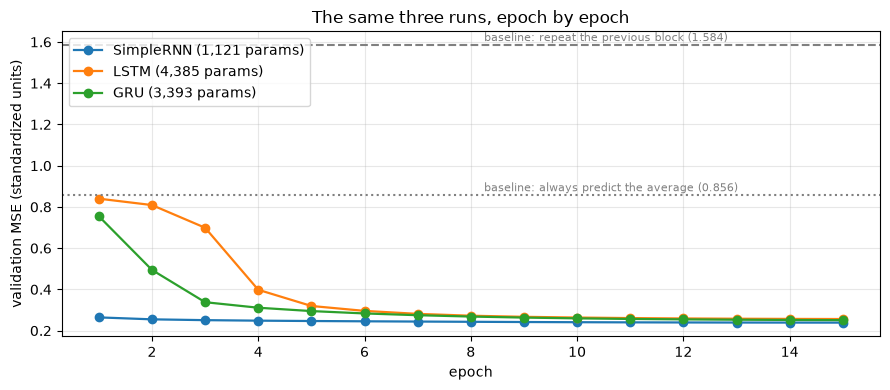

Epoch 1, before any of them knows anything: SimpleRNN 0.264, LSTM 0.840, GRU 0.755
Epoch 15, the numbers in the table above: SimpleRNN 0.239, LSTM 0.256, GRU 0.251

Gap between the best and worst cell at the final epoch : 0.0174
Largest single-epoch move by any curve in the last 5 epochs: 0.0028
The gap between the cells is 6.2x that late-training wobble.
Rule of thumb: below about 3x, stopping one epoch earlier could reorder the podium,
so the ranking is a snapshot rather than a finding. Above it the ordering is at least
stable for THIS seed and THIS slice - which is still one run, not a law.


In [5]:
# WHAT/WHY: the table gives each cell ONE number at the end of training. The histories
# recorded during the same runs show the whole descent — and whether the gap between the
# three curves is a ranking or a coincidence. No retraining: this is the same 15 epochs.
fig, ax = plt.subplots(figsize=(9, 4.0))
for (name, r), color in zip(results.items(), ["tab:blue", "tab:orange", "tab:green"]):
    ax.plot(range(1, EPOCHS + 1), r["history"]["val_loss"], "o-", color=color, lw=1.6,
            label=f"{name} ({r['params']:,} params)")
ax.axhline(mse_persist, ls="--", color="gray")
ax.text(EPOCHS * 0.55, mse_persist + 0.02, "baseline: repeat the previous block "
        f"({mse_persist:.3f})", fontsize=8, color="gray")
ax.axhline(mse_mean, ls=":", color="gray")
ax.text(EPOCHS * 0.55, mse_mean + 0.02, "baseline: always predict the average "
        f"({mse_mean:.3f})", fontsize=8, color="gray")
ax.set_xlabel("epoch"); ax.set_ylabel("validation MSE (standardized units)")
ax.set_title("The same three runs, epoch by epoch")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_spread = (max(r["history"]["val_loss"][-1] for r in results.values())
                - min(r["history"]["val_loss"][-1] for r in results.values()))
wobble = max(abs(r["history"]["val_loss"][e] - r["history"]["val_loss"][e - 1])
             for r in results.values() for e in range(EPOCHS - 5, EPOCHS))
print(f"Epoch 1, before any of them knows anything: "
      + ", ".join(f"{n} {r['history']['val_loss'][0]:.3f}" for n, r in results.items()))
print(f"Epoch {EPOCHS}, the numbers in the table above: "
      + ", ".join(f"{n} {r['history']['val_loss'][-1]:.3f}" for n, r in results.items()))
ratio = final_spread / wobble
print(f"\nGap between the best and worst cell at the final epoch : {final_spread:.4f}")
print(f"Largest single-epoch move by any curve in the last 5 epochs: {wobble:.4f}")
print(f"The gap between the cells is {ratio:.1f}x that late-training wobble.")
# The rule of thumb, stated before the number so it cannot be bent to fit the number.
print("Rule of thumb: below about 3x, stopping one epoch earlier could reorder the podium,")
print("so the ranking is a snapshot rather than a finding. Above it the ordering is at least")
print("stable for THIS seed and THIS slice - which is still one run, not a law.")


### 👀 Read the learning curves

**The first epoch already says something the final table cannot.** The gate-free SimpleRNN is at
**0.264** after a single epoch, while the LSTM sits at **0.840** and the GRU at **0.755** — the cheap
cell has a quarter of the LSTM's parameters, so it has far less to move before it is doing something
useful. On this task the gated cells never close that gap: at epoch 15 the SimpleRNN is still in
front (**0.239**, against GRU **0.251** and LSTM **0.256**).

**The distance worth reporting is vertical, to the grey lines.** "Always predict the training
average" scores **0.856** and "repeat the previous block" scores **1.584**; all three cells finish
near **0.24**. That drop is the skill the network added, and it is about **35 times larger** than
anything separating the three cells from each other.

**Read the two baselines against each other as well.** Repeating the previous value is the *worse*
of the two here, and badly so. With 6-hour blocks the previous value is a different part of the day
— the block before the busy afternoon is the quiet night — so "yesterday, same block" carries
information while "one block ago" is actively misleading. The size of your time bucket decides which
naive baseline is hard to beat.

**And the gap between the coloured curves.** At the final epoch it is **0.0174**, while a single
curve still moves by up to **0.0028** from one epoch to the next this late in training — a factor of
**6.2**. By the rule of thumb printed under the figure that is wide enough not to be an artefact of
where we stopped, so the ordering is stable *for this seed and this slice*. It is still one run.

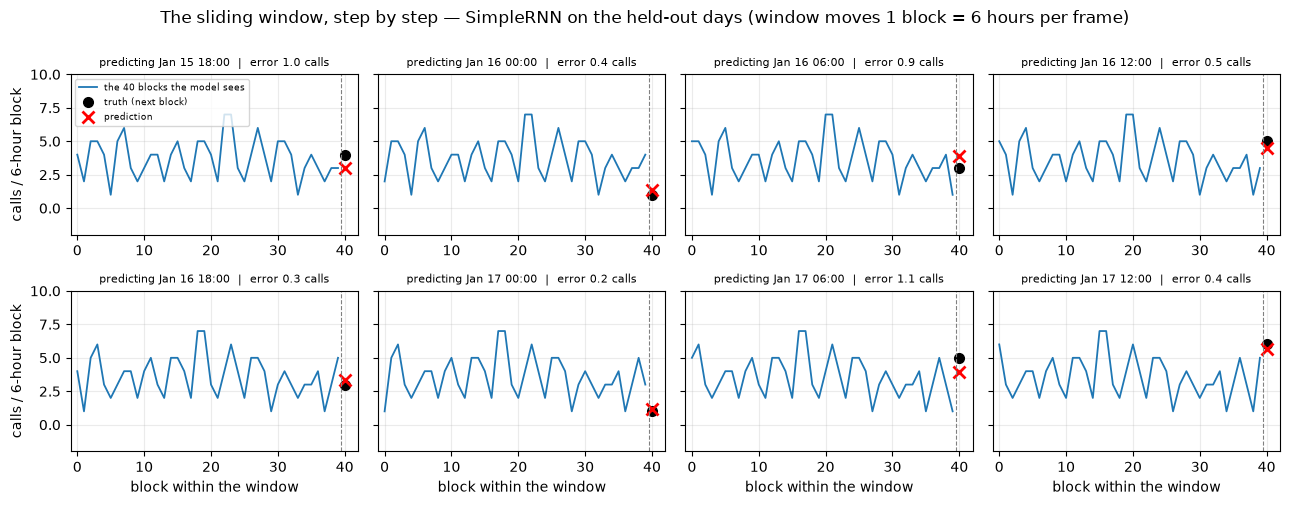

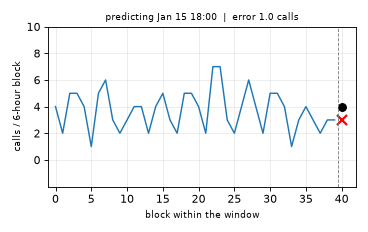

Animation above: 8 frames, the window sliding 6 hours each time.

frame |  target block | last block seen |  truth | predicted |  error
----------------------------------------------------------------------
    1 | Jan 15 18:00 |             3.0 |    4.0 |       3.0 |    1.0
    2 | Jan 16 00:00 |             4.0 |    1.0 |       1.4 |    0.4
    3 | Jan 16 06:00 |             1.0 |    3.0 |       3.9 |    0.9
    4 | Jan 16 12:00 |             3.0 |    5.0 |       4.5 |    0.5
    5 | Jan 16 18:00 |             5.0 |    3.0 |       3.3 |    0.3
    6 | Jan 17 00:00 |             3.0 |    1.0 |       1.2 |    0.2
    7 | Jan 17 06:00 |             1.0 |    5.0 |       3.9 |    1.1
    8 | Jan 17 12:00 |             5.0 |    6.0 |       5.6 |    0.4

Mean error over these eight predictions: 0.6 calls per block (worst 1.1, best 0.2), against a held-out signal that ranges 1 to 8 calls per block.


In [6]:
# WHAT/WHY: "40 past blocks -> the next block" is a sentence; this is the picture. We walk
# the input window forward through the held-out days, one frame per position: the blue
# line is what the model is allowed to see, the black dot is the truth it must hit, the
# red cross is what it predicted. Storyboard first (always renders), then the same frames
# as a GIF. Idiom borrowed from Course 09's course09_step_viz (frames_to_gif_bytes /
# display_gif), inlined so this notebook stands alone. Nothing is retrained.
import io
from PIL import Image
from IPython.display import Image as IPyImage, display

best_name = min(results, key=lambda k: results[k]["val_mse"])
best_pred = preds[best_name]

STEP, N_FRAMES = 1, 8                     # every block (6 hours), 8 positions = 2 days
starts = [i * STEP for i in range(N_FRAMES)]

def raw(v):                               # undo the standardization, for readable axes
    return v * sigma + mu

lo = min(raw(X_val[s, :, 0]).min() for s in starts) - 3
hi = max(raw(X_val[s, :, 0]).max() for s in starts) + 3

def draw_window(ax, s):
    hours = np.arange(WINDOW)
    ax.plot(hours, raw(X_val[s, :, 0]), color="tab:blue", lw=1.3,
            label="the 40 blocks the model sees")
    ax.plot([WINDOW], [raw(y_val[s])], "ko", ms=7, label="truth (next block)")
    ax.plot([WINDOW], [raw(best_pred[s])], "rx", ms=9, mew=2, label="prediction")
    ax.axvline(WINDOW - 0.5, color="gray", lw=0.8, ls="--")
    ax.set_ylim(lo, hi); ax.set_xlim(-1, WINDOW + 2)
    err = abs(raw(best_pred[s]) - raw(y_val[s]))
    ax.set_title(f"predicting {t_val[s]:%b %d %H:%M}  |  error {err:.1f} calls", fontsize=8)

# --- storyboard: all eight positions at once ---
fig, axes = plt.subplots(2, 4, figsize=(13, 5.0), sharey=True)
for ax, s in zip(axes.ravel(), starts):
    draw_window(ax, s)
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=6.5, loc="upper left")
for ax in axes[1]:
    ax.set_xlabel("block within the window")
for ax in axes[:, 0]:
    ax.set_ylabel("calls / 6-hour block")
fig.suptitle(f"The sliding window, step by step — {best_name} on the held-out days "
             f"(window moves {STEP} block = 6 hours per frame)", y=1.0)
plt.tight_layout()
plt.show()

# --- the same eight positions as an animation ---
def frames_to_gif_bytes(frames, duration_ms=900):
    """Encode uint8 RGB frames as one animated GIF (Course 09 step-viz idiom)."""
    imgs = [Image.fromarray(np.asarray(f, dtype=np.uint8)) for f in frames]
    buf = io.BytesIO()
    imgs[0].save(buf, format="GIF", save_all=True, append_images=imgs[1:],
                 duration=duration_ms, loop=0)
    return buf.getvalue()

def fig_to_rgb(fig):
    fig.canvas.draw()
    rgb = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return rgb

frames = []
for s in starts:
    f, ax = plt.subplots(figsize=(4.6, 2.9), dpi=80)
    draw_window(ax, s)
    ax.grid(alpha=0.25)
    ax.set_xlabel("block within the window", fontsize=8)
    ax.set_ylabel("calls / 6-hour block", fontsize=8)
    f.tight_layout()
    frames.append(fig_to_rgb(f))
display(IPyImage(data=frames_to_gif_bytes(frames), format="gif"))

print(f"Animation above: {len(frames)} frames, the window sliding {STEP * 6} hours each time.\n")
print(f"{'frame':>5} | {'target block':>13} | {'last block seen':>15} | {'truth':>6} | "
      f"{'predicted':>9} | {'error':>6}")
print("-" * 70)
errs = []
for fi, s_ in enumerate(starts, start=1):
    last, truth, pred = raw(X_val[s_, -1, 0]), raw(y_val[s_]), raw(best_pred[s_])
    errs.append(abs(pred - truth))
    print(f"{fi:>5} | {t_val[s_]:%b %d %H:%M} | {last:>15.1f} | {truth:>6.1f} | "
          f"{pred:>9.1f} | {abs(pred - truth):>6.1f}")
print(f"\nMean error over these eight predictions: {np.mean(errs):.1f} calls per block "
      f"(worst {max(errs):.1f}, best {min(errs):.1f}), against a held-out signal that "
      f"ranges {raw(y_val).min():.0f} to {raw(y_val).max():.0f} calls per block.")


### 👀 Read the storyboard

Each panel is **one prediction**. Everything left of the dashed line is the model's entire knowledge
of the world at that moment — 40 six-hour call counts, ten days, no calendar, no weather, no holiday
flag — and it must place the red cross on the black dot. Then the window slides one block (six
hours) and it happens again.

**What the eight frames show, from the printed table.** The truth cycles **4 → 1 → 3 → 5** as the day
turns (18:00 busy, 00:00 quiet, 06:00 waking up, 12:00 busy), and the prediction cycles with it:
**3.0 → 1.4 → 3.9 → 4.5**. Look at frames 2 and 3 in particular. Frame 2 has just seen a block of 4
and predicts **1.4**; frame 3 has just seen a block of 1 and predicts **3.9**. The model is not
echoing the last value back at us — it is *inverting* it, because it has learned where in the daily
cycle it stands. That is exactly why "repeat the previous block" scores a dismal **1.584** while the
network scores **0.239**.

**And where it fails.** Frame 7: the window ends on a quiet block of 1, the model predicts 3.9 for
the morning — and the morning ran to 5. Frame 1 is the mirror image: it predicted 3.0 and the
evening delivered 4. Mean error over the eight frames is **0.6 calls per block**, against a held-out
signal that ranges from **1 to 8** calls per block.

That residual is the honest subject of this lesson. A car crash at 09:00 is not written anywhere in
the previous ten days, and no amount of gating will read it there.

### What the numbers say

**On this run the SimpleRNN won**, with a final validation MSE of **0.2389**, ahead of the GRU
(**0.2510**) and the LSTM (**0.2564**). Four honest readings of that table:

1. **All three genuinely forecast.** Predicting the training average for every block scores
   **0.8560** on the held-out months, and repeating the previous block's count scores **1.5842**.
   Every recurrent cell beats both by a wide margin, so the daily rhythm of emergency calls really
   is learnable — the models are not echoing the last value back at us.
2. **The cheapest cell won, and that is not an upset — it is the regime.** Everything these models
   need (where we are in the four-block daily cycle, how busy the last couple of days were) sits
   inside the 40-block input window, and a SimpleRNN handles short dependencies perfectly well. It
   did it with **1,121 parameters against the LSTM's 4,385**. Gates earn their cost on *longer*
   sequences with *long-range* dependencies — remembering something from hundreds of steps ago, as
   in text — where a SimpleRNN's constantly overwritten memory collapses. Nothing in this task asks
   for that, so here the gates are overhead.
3. **The residual error is real-world unpredictability, not a training failure.** A car crash or a
   house fire is not announced by the previous ten days. Compare that with a textbook sine wave,
   where the only thing standing between a model and MSE 0 is noise the author added on purpose. A
   model that drove this validation MSE to 0 would be a warning sign, not a triumph.
4. **A stable ordering is still one run.** The **0.0174** spread survives the epoch-to-epoch wobble
   (**0.0028**) by a factor of **6.2**, so this podium is not an accident of where training stopped
   — which is more than most reported rankings can say. It remains one seed, one 2,000-block slice,
   one epoch budget and one bucket size. The durable lesson is the *mechanism*, not the podium.

## 💬 Discuss

Argue from the table: SimpleRNN **0.2389** (1,121 params), GRU **0.2510** (3,393),
LSTM **0.2564** (4,385); baselines "predict the training average" **0.8560** and
"repeat the previous block" **1.5842**.

1. The three cells are separated by about **7%**, while the gap to the better of the two
   naive baselines is about **72%**. **Which of those two comparisons belongs in your
   report, and which one would a student be tempted to lead with?** Say what would have to
   be true before you would present the 7% as a ranking of architectures.
2. The winner here has a **quarter** of the LSTM's parameters, so on a memory-constrained
   device the SimpleRNN is an easy sell. **Now argue against it** using a property of the
   *task*, not of the numbers — what would have to change about the forecasting problem to
   make the gates pay for themselves?
3. "Repeat the previous block" scored **1.5842** — worse than doing nothing at all
   (**0.8560**). **Explain why**, then say what a fair naive baseline for this data would
   be and roughly what you expect it to score. (Hint: the daily cycle is four blocks long.)
4. This model is scored with MSE, which punishes over- and under-forecasting equally. You
   are staffing ambulance dispatchers for a Saudi city. **Is that symmetry acceptable?**
   Write the loss you would actually want, in words, and say who in the organisation should
   sign off on the asymmetry.
5. Every number above comes from a **25,000-row sample** of a 663,522-row call log,
   aggregated into 6-hour blocks. **Which of the four readings above would you expect to
   survive on the full file, and which one is a property of the bucket size?** Say how you
   would check without downloading anything.

## ⚠️ Where this breaks

The four numbered readings above are the honest interpretation; here are the
conditions under which this whole setup stops working.

- **The 40-block window is a hard horizon.** Anything older than ten days is invisible to
  the model by construction — the month of the year, public holidays, Ramadan timings, a
  heatwave that started three weeks ago. That is a property of the *data preparation*, not
  of the cell type, and no amount of LSTM will recover it.
- **The bucket size is a modelling choice, and it can change the answer.** We count calls in
  6-hour blocks because the bundled sample keeps 1 call in every 27; the same calls counted
  by clock hour average 0.6 and are mostly rounding noise. Re-bucket the series and you are
  running a different experiment. The podium above is a fact about 6-hour blocks of this
  sample, not about SimpleRNN in general — so report the bucket alongside the result.
- **One seed, one slice, one epoch budget.** The ordering here is at least stable against
  the epoch-to-epoch wobble, which is more than most reported comparisons can say — but it
  is still a single run, and treating a single run as a ranking of architectures is the
  single most-copied mistake in student projects.
- **Recurrent models cannot be parallelised across time.** Each step needs the previous
  state, so training time scales with sequence length in a way convolutions and transformers
  do not. On long sequences this is the reason to switch architecture, before accuracy even
  enters the argument.
- **Gates cost parameters and buy nothing when the dependency is short.** Here the LSTM
  spent 4,385 parameters to the SimpleRNN's 1,121 and *lost*, because everything the task
  needs (the four-block daily cycle, the last couple of days) fits inside the window.
  **Cheaper alternatives to check first:** a seasonal-naive baseline ("same block
  yesterday", or "same block last week") or a classical model such as SARIMA. Note how badly
  our simplest baseline — repeat the previous block — did at **1.5842**: a naive baseline
  that ignores the seasonality of the data is not a fair opponent, and beating it proves
  nothing on its own.
- **The split must respect time, and it does here.** Validating on the *later* months is
  what makes this honest; a shuffled split would let the model see the future around each
  validation point and would report a much better number for a much worse model. This is the
  most common way a forecasting project lies to itself.
- **Standardisation was fitted on the training portion.** If you refit the scaler on the
  whole series you leak future statistics into the past — a subtle version of the same
  failure. It is also why "always predict the training average" scores **0.8560** rather
  than exactly 1.0: the held-out months are a little calmer than the training months.
- **An irreducible error floor is normal on real data.** MSE approaching 0 on a real
  emergency-call series would be evidence of leakage, not of skill.

## 📚 References

1. Elman, J. L. (1990). *Finding Structure in Time*. Cognitive Science, 14(2), 179–211.
2. Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation, 9(8), 1735–1780.
3. Cho, K., van Merriënboer, B., Gulcehre, C., et al. (2014). *Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation* (GRU). EMNLP. <https://arxiv.org/abs/1406.1078>
4. Gu, A., & Dao, T. (2023). *Mamba: Linear-Time Sequence Modeling with Selective State Spaces*. arXiv. <https://arxiv.org/abs/2312.00752>
5. Beck, M., Pöppel, K., Spanring, M., et al. (2024). *xLSTM: Extended Long Short-Term Memory*. arXiv. <https://arxiv.org/abs/2405.04517>
6. Ansari, A. F., Shchur, O., Küken, J., et al. (2025). *Chronos-2: From Univariate to Universal Forecasting*. arXiv. <https://arxiv.org/abs/2510.15821>